In [54]:
import pandas as pd
from pathlib import Path


folder = Path(".").resolve().parent.parent / "experiments" / "protein" / "hyper"


nn_names = ["le", "moe"]
data: dict[str, pd.DataFrame] = dict()

for run in folder.iterdir():

    if not run.is_dir():
        continue

    name = run.name.split("_")[2]

    if name not in data:
        data[name] = []

    df = pd.read_csv(run / f"{name}.csv")
    data[name].append(df)


corrective_RMSE_factor = 1
data = {name: pd.concat(dfs) for name, dfs in data.items()}

In [55]:
for name, df in data.items():
    print(name, df.shape[0])

lgbm 1800
rf 3582
moe 778
le 436


In [56]:
assert (data["le"]["best_rmse_results"] <= data["le"]["rmse_results"]).all()
assert (data["moe"]["best_rmse_results"] <= data["moe"]["rmse_results"]).all()

In [60]:
corrective_RMSE_factor

6.112627029418945

### Correct not denormed nn adapter

In [57]:
from liquid.train import load_protein

dataset, _ = load_protein()
corrective_RMSE_factor = dataset.tensors[1].std().item()

def correct(rmse: pd.Series, T: float=0.75):
    correct_mask = rmse < T
    rmse = rmse.copy()
    rmse[correct_mask] = rmse[correct_mask] * corrective_RMSE_factor
    return rmse

data["le"]["best_rmse_results"] = correct(data["le"]["best_rmse_results"])
data["le"]["rmse_results"] = correct(data["le"]["rmse_results"])
data["moe"]["rmse_results"] = correct(data["moe"]["rmse_results"])
data["moe"]["best_rmse_results"] = correct(data["moe"]["best_rmse_results"])

### Pure rmse look

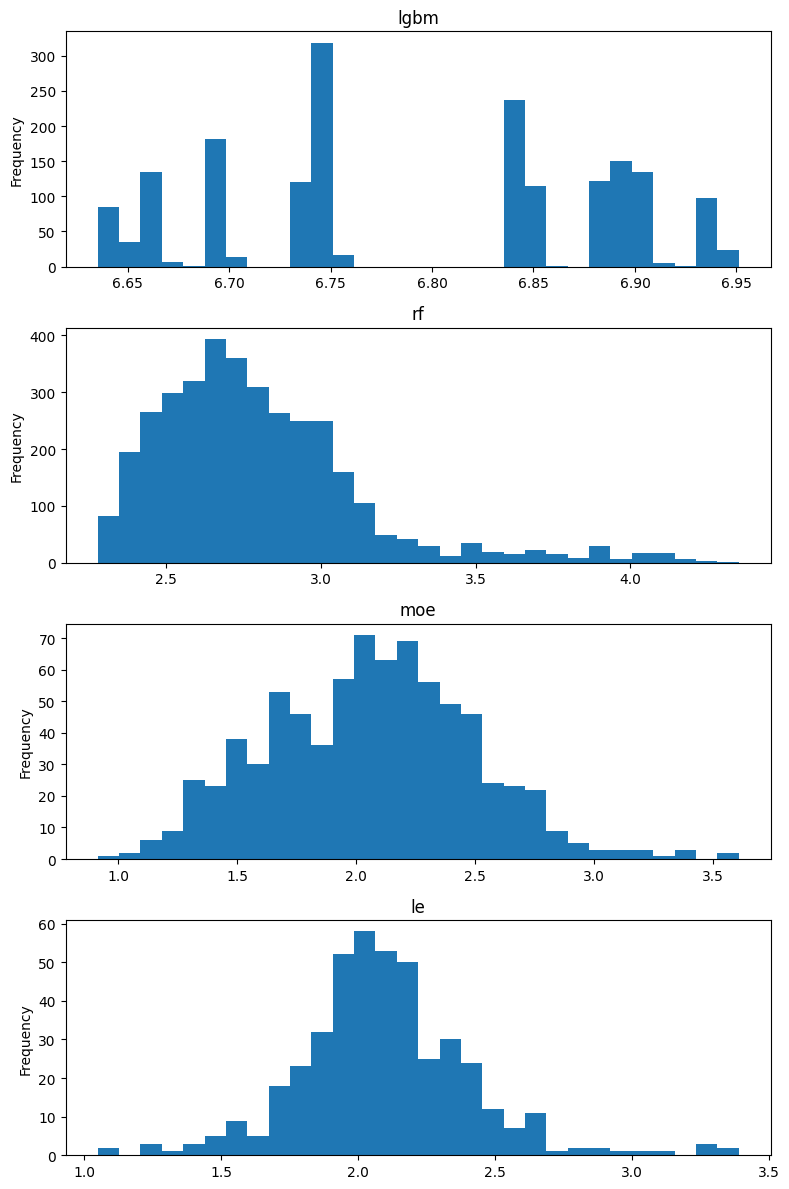

In [59]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(len(data), 1, figsize=(8, 3 * len(data)))

for (name, df), ax in zip(data.items(), axs):
    metric_name = "best_rmse_results" if name in nn_names else "rmse_results"
    metric = df[metric_name]

    metric.plot.hist(bins=30, ax=ax)
    ax.set_title(name)


fig.tight_layout()


### Nbytes over RMSE

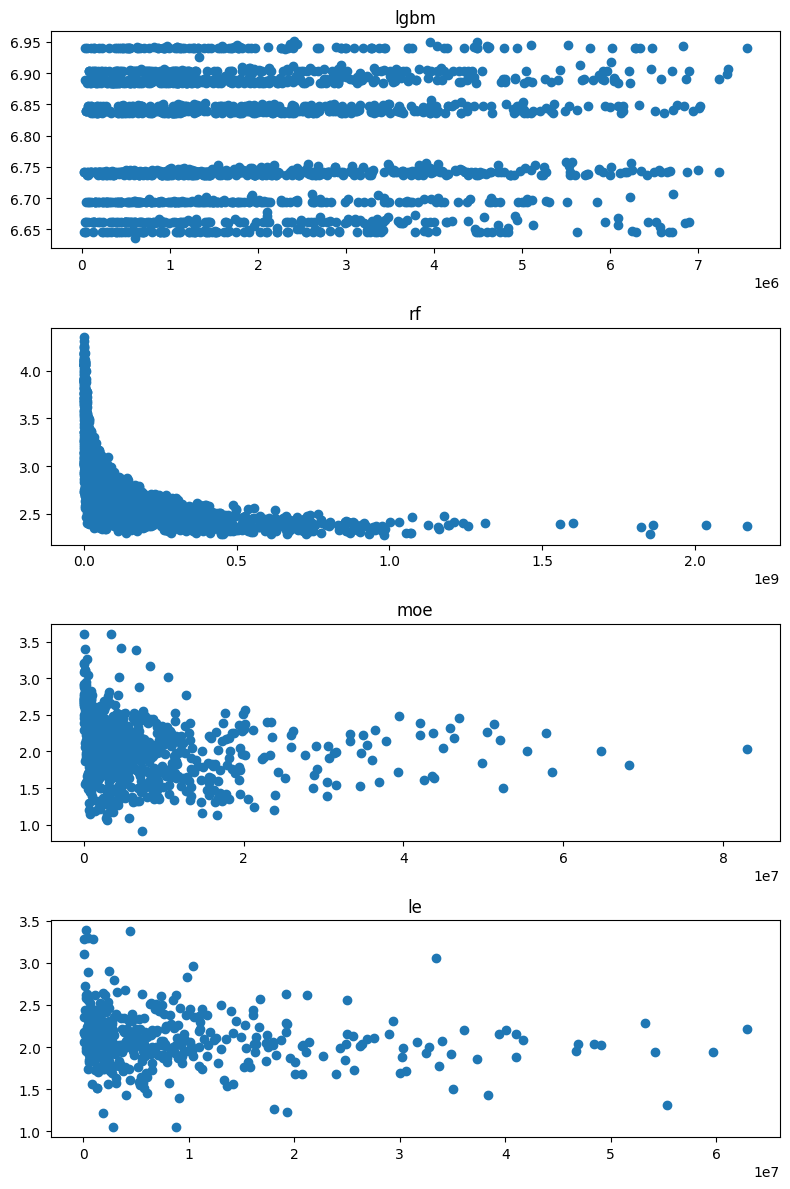

In [66]:
import numpy as np

fig, axs = plt.subplots(len(data), 1, figsize=(8, 3 * len(data)))

for (name, df), ax in zip(data.items(), axs):

    metric_name = "best_rmse_results" if name in nn_names else "rmse_results"

    x = df["nbytes_results"].to_numpy()
    y = df[metric_name].to_numpy()

    ax.scatter(x, y)
    ax.set_title(name)


fig.tight_layout()

### Shapley value

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

import shapiq

def get_inputs(df: pd.DataFrame) -> pd.DataFrame:

    exclude = [
    "batch_size",
    "name",
    "verbose",
    "n_input",
    "n_output",
    "solver"
    ] + df.columns[df.columns.str.contains("results")].tolist()

    exclude.remove("train_time_results")
    exclude.remove("nbytes_results")

    return df.drop(columns=exclude, errors="ignore")

def to_numpy(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:

    df = df.copy()

    ok_columns = df.select_dtypes(include='number').columns
    bad_columns = df.columns[~df.columns.isin(ok_columns)]

    if bad_columns.size == 0:
        return df.to_numpy(), df.columns.to_numpy()

    print(bad_columns.tolist(), "will be converted to categorical value")

    for col in bad_columns:
        df[col] = df[col].astype("category").cat.codes


    return df.to_numpy(), df.columns.to_numpy()


def check_for_too_large_errors(X: np.ndarray, y: np.ndarray, model: RandomForestRegressor):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, yhat)
    print("Surrogate model validation rmse", rmse)



def explain_model_metric(df: pd.DataFrame, metric: str):

    surrogate = RandomForestRegressor(n_estimators=100, warm_start=False)

    X, feature_names = to_numpy(get_inputs(df))
    y = df[metric].to_numpy()

    check_for_too_large_errors(X, y, surrogate)

    surrogate.fit(X, y)

    # TODO finish shapley

    explainer = shapiq.TabularExplainer(
        model=surrogate,
        data=X,
        index="k-SII",
        max_order=3
    )

    explanations = explainer.explain_X(
        X,
        budget=256,
        n_jobs=3

    )

    # shapiq.network_plot(
    #     interaction_values=interaction_values,
    #     feature_names=feature_names,
    # )

    return explanations, feature_names



explanations, feature_names = explain_model_metric(data["le"], "best_rmse_results")

Surrogate model validation rmse 0.3462686019420198


TypeError: unsupported operand type(s) for /: 'InteractionValues' and 'float'

In [ ]:
from shapiq.interaction_values import aggregate_interaction_values

global_explanation = aggregate_interaction_values(explanations, aggregation="mean")

In [ ]:
global_explanation.plot_force()

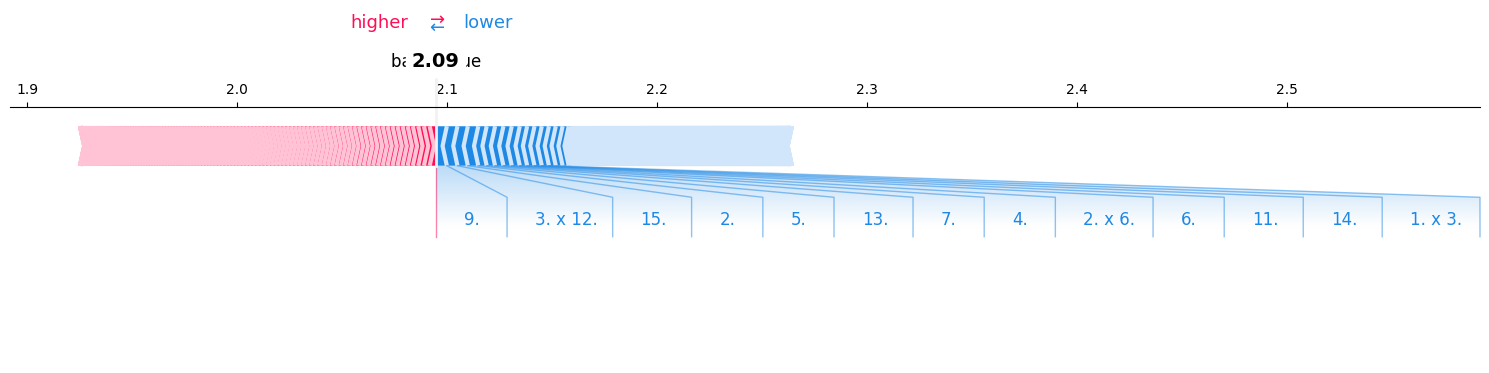

In [163]:
global_explanation.plot_force(contribution_threshold=0.01)

In [145]:
(explanations[0].get_n_order_values(2)[0, 1] + explanations[1].get_n_order_values(2)[0, 1])

np.float64(0.029599423388365395)

In [ ]:
df["solver"].astype("category").cat.codes.unique()

array([0], dtype=int8)

In [103]:
data["rf"].select_dtypes("object")

,name
0,protein
1,protein
2,protein
3,protein
4,protein
...,...
571,protein
572,protein
573,protein
574,protein
